Import Libraries

In [ ]:
import numpy as np
import pandas as pd

from sklearn.datasets import fetch_california_housing # Removed load_boston
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

Load Dataset (Regression Example)

In [ ]:
data = fetch_california_housing()
X = data.data
y = data.target

Train–Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Train a Baseline Model

In [ ]:
model = DecisionTreeRegressor(random_state=42)
model.fit(X_train, y_train)

DecisionTreeRegressor(random_state=42)

Evaluate Baseline Model

In [ ]:
y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Baseline RMSE:", rmse)
print("Baseline R2 Score:", r2)

Baseline RMSE: 0.7037294974840077
Baseline R2 Score: 0.622075845135081


Cross-Validation (K-Fold)

In [ ]:
cv_scores = cross_val_score(
    model, X_train, y_train,
    scoring="neg_mean_squared_error",
    cv=5
)

cv_rmse = np.sqrt(-cv_scores)

print("Cross-Validation RMSE Scores:", cv_rmse)
print("Average CV RMSE:", cv_rmse.mean())

Cross-Validation RMSE Scores: [0.75341387 0.73444956 0.70174445 0.72871242 0.70172611]
Average CV RMSE: 0.7240092833935426


Hyperparameter Tuning (GridSearchCV)

In [ ]:
param_grid = {
    "max_depth": [2, 4, 6, 8, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

grid = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

grid.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=DecisionTreeRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [2, 4, 6, 8, None],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10]},
             scoring='neg_mean_squared_error')

Best Parameters

In [ ]:
print("Best Parameters:", grid.best_params_)

Best Parameters: {'max_depth': 8, 'min_samples_leaf': 4, 'min_samples_split': 10}


Train Tuned Model

In [ ]:
best_model = grid.best_estimator_
best_model.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=8, min_samples_leaf=4, min_samples_split=10,
                      random_state=42)

Evaluate Tuned Model

In [ ]:
y_pred_tuned = best_model.predict(X_test)

rmse_tuned = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
r2_tuned = r2_score(y_test, y_pred_tuned)

print("Tuned RMSE:", rmse_tuned)
print("Tuned R2 Score:", r2_tuned)

Tuned RMSE: 0.6463096283229604
Tuned R2 Score: 0.6812322392481562


Compare Models

In [ ]:
print("Baseline RMSE :", rmse)
print("Tuned RMSE    :", rmse_tuned)

if rmse_tuned < rmse:
    print("Tuned model performs better and reduces overfitting.")
else:
    print("Baseline model performs better.")

Baseline RMSE : 0.7037294974840077
Tuned RMSE    : 0.6463096283229604
Tuned model performs better and reduces overfitting.


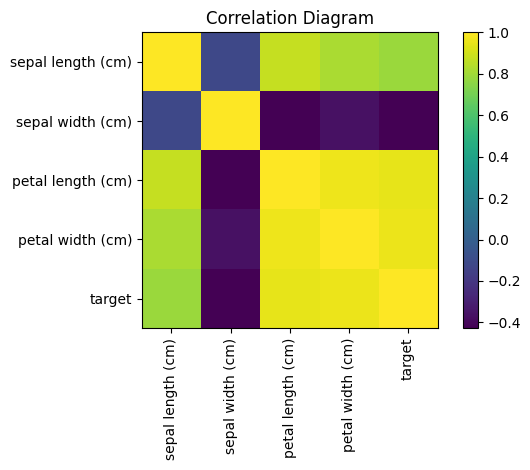

In [ ]:
data = load_iris(as_frame=True)
df = data.frame

corr = df.corr()

plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Diagram")
plt.tight_layout()
plt.show()
